## Q1 (frequency-domain U-Net)

Reiterate the 1D U-Net reconstruction and latent-space clustering pipeline, but using **frequency-domain transformed traces** as input to the network instead of raw time-domain traces.

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

# Load original time-domain data
data = np.load("./SiesmicEventsClassification_Normalized.npz")
X_time = data["data"]  # (N, 6000)
y = data["label"]

# Frequency-domain transform: magnitude of 1D FFT along time axis
X_freq_complex = np.fft.rfft(X_time, axis=1)
X_freq = np.abs(X_freq_complex).astype(np.float32)  # (N, L_freq)

print("Time-domain shape:", X_time.shape)
print("Freq-domain shape:", X_freq.shape)

# Train / test split on frequency-domain data (same random_state for comparability)
X_train, X_test, y_train, y_test = train_test_split(
    X_freq, y, test_size=0.2, random_state=42
)

# Save a separate NPZ so unet_search.py can consume it without overwriting the original
np.savez("SiesmicEventsClassification_Freq_Normalized.npz", data=X_freq, label=y)

Time-domain shape: (1000, 6000)
Freq-domain shape: (1000, 3001)


### U-Net (1D) architecture search on frequency-domain traces

We now run the same 1D U-Net architecture search, but using the frequency-domain magnitudes as inputs/targets. Results are logged to a new JSONL file and the best checkpoint is saved under a new filename.

In [19]:
# Runs a grid search on the frequency-domain data.
# Note the different --data, --results, and --save-best arguments.
!python unet_search.py \
  --data SiesmicEventsClassification_Freq_Normalized.npz \
  --epochs 20 --patience 3 --batch 64 \
  --results unet_search_results_freq.jsonl \
  --save-best best_unet1d_freq.pt

Best UNet1DConfig: UNet1DConfig(in_channels=1, out_channels=1, depth=3, base_channels=32, channel_mult=2, kernel_size=3, norm='none', dropout=0.0, residual=True)
Best val MSE:  0.13262943
Best test MSE: 0.13242042
Saved: best_unet1d_freq.pt
Trials log: unet_search_results_freq.jsonl


In [20]:
import torch
from unet1d import UNet1D, UNet1DConfig

# Load the best frequency-domain model checkpoint
ckpt_freq = torch.load("best_unet1d_freq.pt", map_location="cpu")
best_cfg_freq = UNet1DConfig(**ckpt_freq["cfg"])
print("Best config (freq):", best_cfg_freq)
print("Best val MSE (freq):", ckpt_freq["best_val_mse"])
print("Best test MSE (freq):", ckpt_freq["best_test_mse"])

Best config (freq): UNet1DConfig(in_channels=1, out_channels=1, depth=3, base_channels=32, channel_mult=2, kernel_size=3, norm='none', dropout=0.0, residual=True)
Best val MSE (freq): 0.1326294327672026
Best test MSE (freq): 0.13242042284733213


C:\Users\wkkong\AppData\Local\Temp\ipykernel_12508\4160947743.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_freq = torch.load("best_unet1d_freq.pt", map_location=

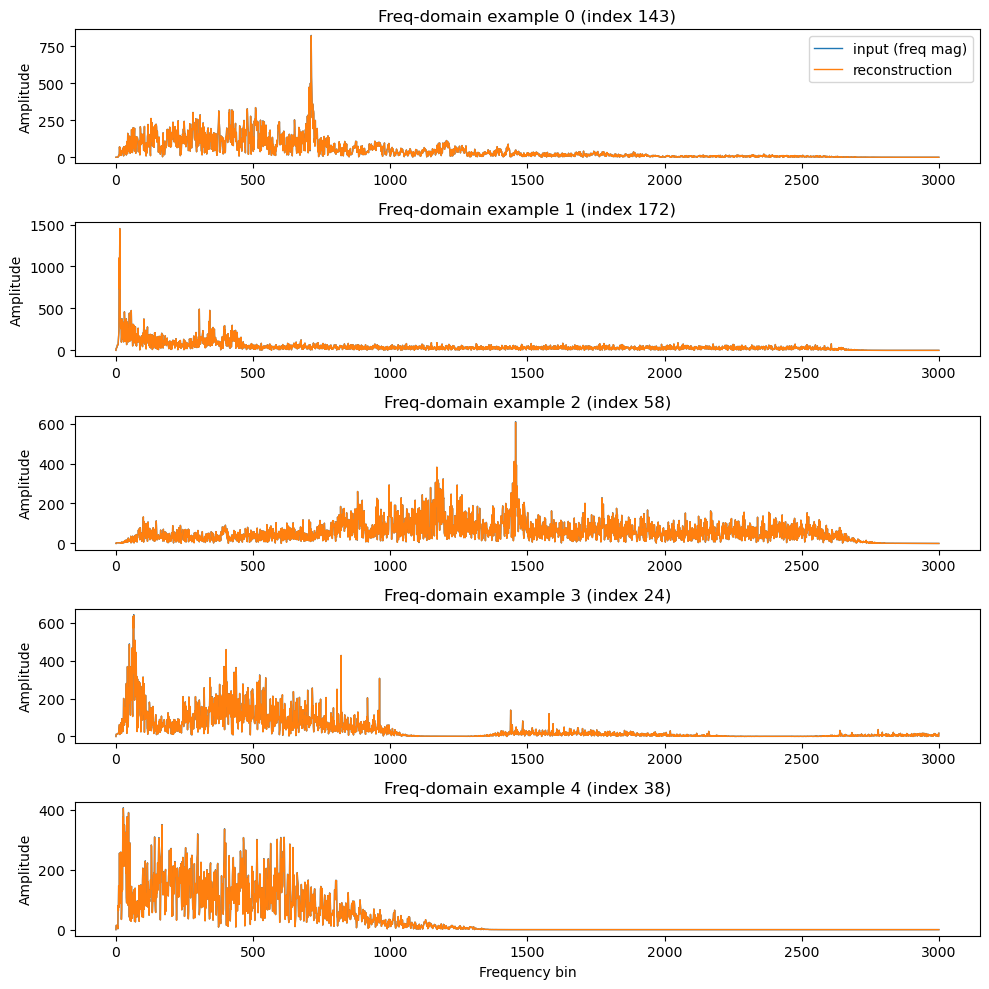

In [21]:
import matplotlib.pyplot as plt

# Build model from the best frequency-domain configuration and checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_freq = UNet1D(best_cfg_freq).to(device)
model_freq.load_state_dict(ckpt_freq["state_dict"])
model_freq.eval()

# Visualize reconstruction quality on a few frequency-domain traces from the test set
num_examples = 5
idx = np.random.choice(len(X_test), size=num_examples, replace=False)

with torch.no_grad():
    x = torch.from_numpy(X_test[idx]).float().unsqueeze(1).to(device)  # (B, 1, L_freq)
    pred = model_freq(x).cpu().squeeze(1).numpy()  # (B, L_freq)

plt.figure(figsize=(10, 2 * num_examples))
for i, k in enumerate(idx):
    plt.subplot(num_examples, 1, i + 1)
    plt.plot(X_test[k], label="input (freq mag)", linewidth=1)
    plt.plot(pred[i], label="reconstruction", linewidth=1)
    plt.title(f"Freq-domain example {i} (index {k})")
    if i == 0:
        plt.legend(loc="upper right")
    plt.ylabel("Amplitude")

plt.xlabel("Frequency bin")
plt.tight_layout()
plt.show()

### K-means clustering on frequency-domain bottleneck features

We now repeat the PCA + K-means clustering pipeline using latent features extracted from the frequency-domain U-Net.

In [22]:
from latent_clustering import (
    load_best_unet,
    extract_bottleneck_features,
    run_pca_kmeans,
    pca_2d_for_visualization,
)

# Load the trained best frequency-domain UNet model and its config
model_f, best_cfg_f, ckpt_f = load_best_unet("best_unet1d_freq.pt")
print("Best config (freq):", best_cfg_f)
print("Best val MSE (freq):", ckpt_f["best_val_mse"])
print("Best test MSE (freq):", ckpt_f["best_test_mse"])

Best config (freq): UNet1DConfig(in_channels=1, out_channels=1, depth=3, base_channels=32, channel_mult=2, kernel_size=3, norm='none', dropout=0.0, residual=True)
Best val MSE (freq): 0.1326294327672026
Best test MSE (freq): 0.13242042284733213


d:\KAUST\semster2\ML_IN_GEO\assignment4\latent_clustering.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt: dict[str, Any] = torch.load(ckpt_path, map_location=devi

In [23]:
# Extract bottleneck latent features for the frequency-domain test set traces
# X_test has shape (N_test, L_freq)
X_test_latent_f = extract_bottleneck_features(model_f, X_test, batch_size=128)
print("Latent feature shape (freq):", X_test_latent_f.shape)

# Run PCA (to 10D by default) + K-means clustering into 2 clusters
clu_result_f = run_pca_kmeans(
    X_test_latent_f,
    n_components_pca=10,
    n_clusters=2,
)

print("PCA latent shape (freq):", clu_result_f.latent_pca.shape)
print("Cluster labels shape (freq):", clu_result_f.cluster_labels.shape)

Latent feature shape (freq): (200, 96128)
PCA latent shape (freq): (200, 10)
Cluster labels shape (freq): (200,)


d:\anaconda3\envs\torch_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


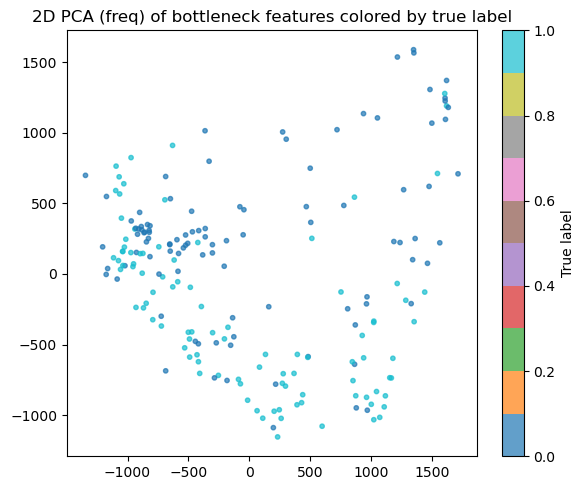

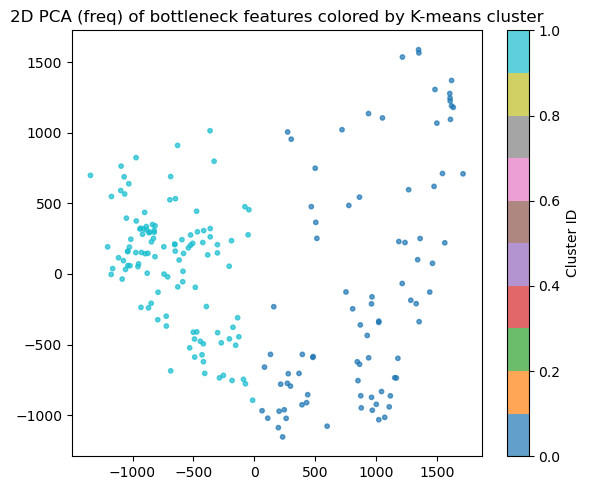

Adjusted Rand Index (ARI) between true labels and clusters (freq): -1.918987421037455e-05
Confusion matrix (true label vs cluster) for freq-domain features:
[[40 62]
 [45 53]]


In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# 2D PCA coordinates for visualization (separate from the 10D used for clustering)
coords_2d_f, pca_2d_f = pca_2d_for_visualization(X_test_latent_f)

# Scatter plot colored by true labels
plt.figure(figsize=(6, 5))
scatter = plt.scatter(coords_2d_f[:, 0], coords_2d_f[:, 1], c=y_test, cmap="tab10", s=10, alpha=0.7)
plt.title("2D PCA (freq) of bottleneck features colored by true label")
plt.colorbar(scatter, label="True label")
plt.tight_layout()
plt.show()

# Scatter plot colored by K-means cluster assignments
plt.figure(figsize=(6, 5))
scatter = plt.scatter(coords_2d_f[:, 0], coords_2d_f[:, 1], c=clu_result_f.cluster_labels, cmap="tab10", s=10, alpha=0.7)
plt.title("2D PCA (freq) of bottleneck features colored by K-means cluster")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.show()

# Quantitative agreement between clusters and true labels
ari_f = adjusted_rand_score(y_test, clu_result_f.cluster_labels)
print("Adjusted Rand Index (ARI) between true labels and clusters (freq):", ari_f)

print("Confusion matrix (true label vs cluster) for freq-domain features:")
print(confusion_matrix(y_test, clu_result_f.cluster_labels))